# Assignment 12 — Descriptive Statistics on Wine + Iris Datasets

## Topic Explanation

### What is Descriptive Statistics?
**Descriptive Statistics** is the branch of statistics that summarizes and describes the main features of a dataset using **numbers** rather than predictions. It answers questions like:
- What's the typical value? (central tendency)
- How spread out are the values? (variability)
- What's the shape of the distribution?

It's the **first thing** you do when exploring any new dataset — before any modeling.

### Compare with Inferential Statistics
- **Descriptive** — summarizes the data you have
- **Inferential** — makes predictions/generalizations from a sample to a larger population (hypothesis tests, confidence intervals, regression)

### Two Categories of Descriptive Statistics

#### 1. Measures of Central Tendency
"Where is the center of the data?"

| Measure | Formula | When to Use |
|---------|---------|-------------|
| **Mean** | Σx / n | Symmetric data without outliers |
| **Median** | Middle value when sorted | Skewed data or outliers present |
| **Mode** | Most frequent value | Categorical data |

- **Mean** is sensitive to outliers — one extreme value drags it
- **Median** is robust — only the position matters
- **Mode** can be used for any data type

#### 2. Measures of Variability (Dispersion)
"How spread out is the data?"

| Measure | Formula | Meaning |
|---------|---------|---------|
| **Range** | max − min | Total spread |
| **Variance** | Σ(x − mean)² / (n−1) | Average squared deviation |
| **Standard Deviation** | √variance | Spread in original units |
| **IQR** | Q3 − Q1 | Spread of middle 50% |

- **Range** is simple but only uses two values
- **Standard deviation** uses all values; same units as the data
- **IQR** is robust to outliers

### Percentiles and Quartiles

A **percentile** is the value below which a given % of data falls:
- **25th percentile (Q1)** — first quartile, 25% of data is below this
- **50th percentile (Q2 / Median)** — second quartile, half the data is below
- **75th percentile (Q3)** — third quartile, 75% of data is below

### Group-Wise Statistics
Often the most useful insight comes from **summarizing within groups** rather than across the whole dataset. For example:
- Average income across all people may be misleading
- Average income **grouped by age group** reveals real patterns

In pandas this is done with **`.groupby('column').agg([statistics])`**.

### About the Datasets

#### Wine Dataset
A classic ML dataset from `sklearn.datasets.load_wine()`. Contains 178 wines and 13 chemical properties (alcohol, malic acid, ash, magnesium, phenols, etc.) with a `class` label (3 cultivars).

#### Iris Dataset
The most famous dataset in ML. 150 iris flowers across 3 species (setosa, versicolor, virginica), each described by 4 measurements (sepal length, sepal width, petal length, petal width).

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations, groupby, describe
import pandas as pd

# numpy — numerical operations
import numpy as np

# matplotlib & seaborn — visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## Part 1: Wine Dataset — Group-wise Summary Statistics

### Step 2: Load the Wine Dataset

In [2]:
# Load the wine dataset
df = pd.read_csv('wine.csv')
print("Shape:", df.shape)
df.head()

Shape: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [3]:
# Inspect column types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  class           

In [4]:
# Quick preview of class distribution — this is our categorical (grouping) variable
print("Class distribution:")
print(df['class'].value_counts())

Class distribution:
class
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


### Step 3: Summary Statistics — Whole Dataset

`describe()` returns count, mean, std, min, 25%, 50% (median), 75%, max for every numeric column.

In [5]:
# Whole-dataset summary
df.describe().round(3)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,13.001,2.336,2.367,19.495,99.742,2.295,2.029,0.362,1.591,5.058,0.957,2.612,746.893
std,0.812,1.117,0.274,3.340,14.282,0.626,0.999,0.124,0.572,2.318,0.229,0.710,314.907
min,11.030,0.740,1.360,10.600,70.000,0.980,0.340,0.130,0.410,1.280,0.480,1.270,278.000
25%,12.362,1.602,2.210,17.200,88.000,1.742,1.205,0.270,1.250,3.220,0.782,1.938,500.500
50%,13.050,1.865,2.360,19.500,98.000,2.355,2.135,0.340,1.555,4.690,0.965,2.780,673.500
75%,13.678,3.082,2.558,21.500,107.000,2.800,2.875,0.438,1.950,6.200,1.120,3.170,985.000
max,14.830,5.800,3.230,30.000,162.000,3.880,5.080,0.660,3.580,13.000,1.710,4.000,1680.000


### Step 4: Summary Statistics Grouped by `class`

This is the core of the assignment — group numeric variables by the categorical `class` variable.

In [6]:
# Group by class and compute multiple statistics for each numeric column
grouped = df.groupby('class').agg(['mean', 'median', 'min', 'max', 'std']).round(3)

print("Group-wise summary statistics (every numeric variable):")
grouped

Group-wise summary statistics (every numeric variable):


alcohol                              malic_acid                     \
           mean  median    min    max    std       mean median   min   max   
class                                                                        
class_0  13.745  13.750  12.85  14.83  0.462      2.011  1.770  1.35  4.04   
class_1  12.279  12.290  11.03  13.86  0.538      1.933  1.610  0.74  5.80   
class_2  13.154  13.165  12.20  14.34  0.530      3.334  3.265  1.24  5.65   

                ... od280/od315_of_diluted_wines                            \
           std  ...                         mean median   min   max    std   
class           ...                                                          
class_0  0.689  ...                        3.158   3.17  2.51  4.00  0.357   
class_1  1.016  ...                        2.785   2.83  1.59  3.69  0.497   
class_2  1.088  ...                        1.684   1.66  1.27  2.47  0.272   

          proline                                  
             mean  median    min     max      std  
class                                              
class_0  1115.712  1095.0  680.0  1680.0  221.521  
class_1   519.507   495.0  278.0   985.0  157.211  
class_2   629.896   627.5  415.0   880.0  115.097  

[3 rows x 65 columns]

### Step 5: Focus on a Few Key Variables

For clarity, let's look at three important variables: `alcohol`, `malic_acid`, `total_phenols`.

In [7]:
key_vars = ['alcohol', 'malic_acid', 'total_phenols']

# Group by class, summarize the three key variables
df.groupby('class')[key_vars].agg(['mean', 'median', 'min', 'max', 'std']).round(3)

alcohol                              malic_acid                     \
           mean  median    min    max    std       mean median   min   max   
class                                                                        
class_0  13.745  13.750  12.85  14.83  0.462      2.011  1.770  1.35  4.04   
class_1  12.279  12.290  11.03  13.86  0.538      1.933  1.610  0.74  5.80   
class_2  13.154  13.165  12.20  14.34  0.530      3.334  3.265  1.24  5.65   

               total_phenols                            
           std          mean median   min   max    std  
class                                                   
class_0  0.689         2.840  2.800  2.20  3.88  0.339  
class_1  1.016         2.259  2.200  1.10  3.52  0.545  
class_2  1.088         1.679  1.635  0.98  2.80  0.357

### Step 6: Create a List Containing a Numeric Value Per Category

The assignment asks for "a list that contains a numeric value for each response to the categorical variable." This means: for each class, compute one number (e.g., mean alcohol).

In [8]:
# Mean alcohol per class — produces 3 numbers (one per class)
alcohol_per_class = df.groupby('class')['alcohol'].mean().tolist()
print("Categories:", df['class'].unique().tolist())
print("Mean alcohol per class:", [round(x, 3) for x in alcohol_per_class])

Categories: ['class_0', 'class_1', 'class_2']
Mean alcohol per class: [13.745, 12.279, 13.154]


In [9]:
# Same approach for several variables
for var in key_vars:
    means = df.groupby('class')[var].mean().tolist()
    print(f"Mean {var:<20} per class: {[round(x, 3) for x in means]}")

Mean alcohol              per class: [13.745, 12.279, 13.154]
Mean malic_acid           per class: [2.011, 1.933, 3.334]
Mean total_phenols        per class: [2.84, 2.259, 1.679]


### Step 7: Visualize Group Differences

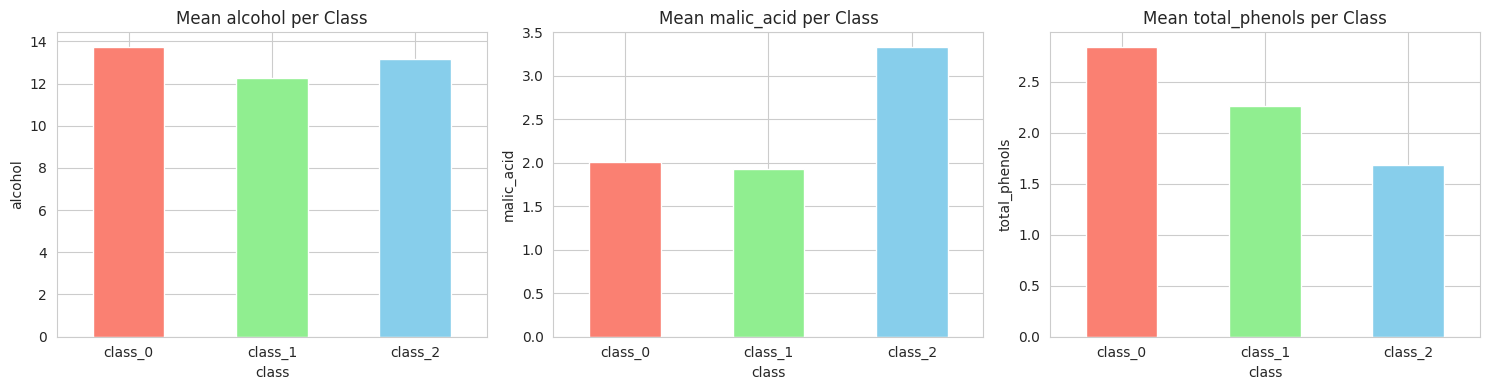

In [10]:
# Bar plot — mean of each key variable per class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var in zip(axes, key_vars):
    df.groupby('class')[var].mean().plot(kind='bar', ax=ax, color=['salmon','lightgreen','skyblue'])
    ax.set_title(f'Mean {var} per Class')
    ax.set_ylabel(var)
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

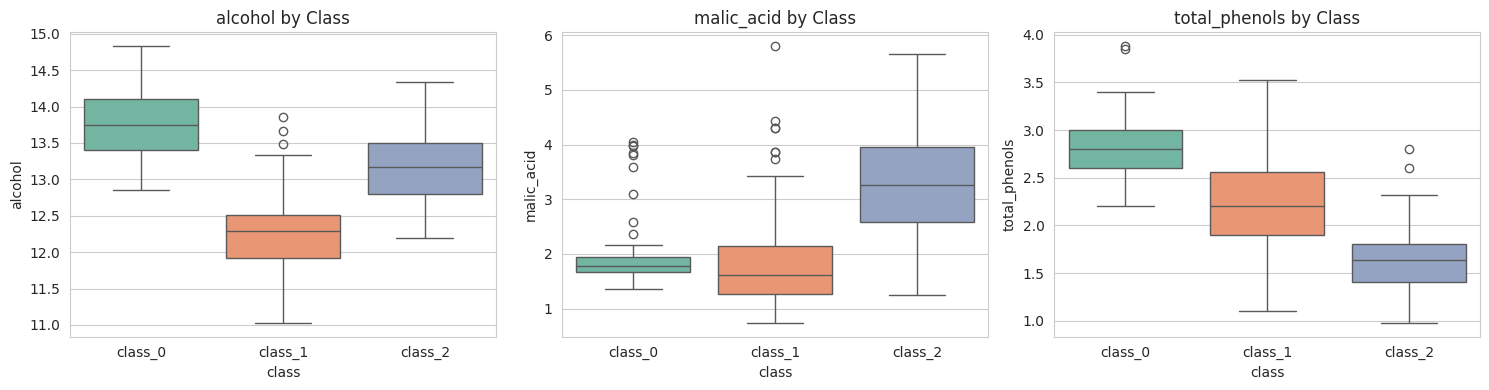

In [11]:
# Boxplots — show distribution per class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var in zip(axes, key_vars):
    sns.boxplot(x='class', y=var, data=df, ax=ax, hue='class', palette='Set2', legend=False)
    ax.set_title(f'{var} by Class')

plt.tight_layout()
plt.show()

## Part 2: Iris Dataset — Per-Species Statistics

### Step 8: Load the Iris Dataset

In [12]:
# Load the Iris dataset
iris = pd.read_csv('iris.csv')
print("Shape:", iris.shape)
iris.head()

Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [13]:
# Class distribution — 50 each is typical
print("Species distribution:")
print(iris['species'].value_counts())

Species distribution:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


### Step 9: Statistical Details of `Iris-setosa`

`describe()` automatically gives count, mean, std, min, 25/50/75 percentiles, max.

In [14]:
# Filter to setosa rows only, then describe
setosa_stats = iris[iris['species'] == 'Iris-setosa'].describe().round(3)
print("Iris-setosa — statistical summary:")
setosa_stats

Iris-setosa — statistical summary:


,sepal_length,sepal_width,petal_length,petal_width
count,50.000,50.000,50.000,50.000
mean,5.006,3.428,1.462,0.246
std,0.352,0.379,0.174,0.105
min,4.300,2.300,1.000,0.100
25%,4.800,3.200,1.400,0.200
50%,5.000,3.400,1.500,0.200
75%,5.200,3.675,1.575,0.300
max,5.800,4.400,1.900,0.600


### Step 10: Statistical Details of `Iris-versicolor`

In [15]:
versicolor_stats = iris[iris['species'] == 'Iris-versicolor'].describe().round(3)
print("Iris-versicolor — statistical summary:")
versicolor_stats

Iris-versicolor — statistical summary:


,sepal_length,sepal_width,petal_length,petal_width
count,50.000,50.000,50.00,50.000
mean,5.936,2.770,4.26,1.326
std,0.516,0.314,0.47,0.198
min,4.900,2.000,3.00,1.000
25%,5.600,2.525,4.00,1.200
50%,5.900,2.800,4.35,1.300
75%,6.300,3.000,4.60,1.500
max,7.000,3.400,5.10,1.800


### Step 11: Statistical Details of `Iris-virginica`

In [16]:
virginica_stats = iris[iris['species'] == 'Iris-virginica'].describe().round(3)
print("Iris-virginica — statistical summary:")
virginica_stats

Iris-virginica — statistical summary:


,sepal_length,sepal_width,petal_length,petal_width
count,50.000,50.000,50.000,50.000
mean,6.588,2.974,5.552,2.026
std,0.636,0.322,0.552,0.275
min,4.900,2.200,4.500,1.400
25%,6.225,2.800,5.100,1.800
50%,6.500,3.000,5.550,2.000
75%,6.900,3.175,5.875,2.300
max,7.900,3.800,6.900,2.500


### Step 12: Compare All Species Side-by-Side

In [17]:
# Use groupby to show all species in one combined table
iris.groupby('species').agg(['mean', 'median', 'std', 'min', 'max']).round(3)

sepal_length                         sepal_width         \
                        mean median    std  min  max        mean median   
species                                                                   
Iris-setosa            5.006    5.0  0.352  4.3  5.8       3.428    3.4   
Iris-versicolor        5.936    5.9  0.516  4.9  7.0       2.770    2.8   
Iris-virginica         6.588    6.5  0.636  4.9  7.9       2.974    3.0   

                                 petal_length                          \
                   std  min  max         mean median    std  min  max   
species                                                                 
Iris-setosa      0.379  2.3  4.4        1.462   1.50  0.174  1.0  1.9   
Iris-versicolor  0.314  2.0  3.4        4.260   4.35  0.470  3.0  5.1   
Iris-virginica   0.322  2.2  3.8        5.552   5.55  0.552  4.5  6.9   

                petal_width                          
                       mean median    std  min  max  
species                                              
Iris-setosa           0.246    0.2  0.105  0.1  0.6  
Iris-versicolor       1.326    1.3  0.198  1.0  1.8  
Iris-virginica        2.026    2.0  0.275  1.4  2.5

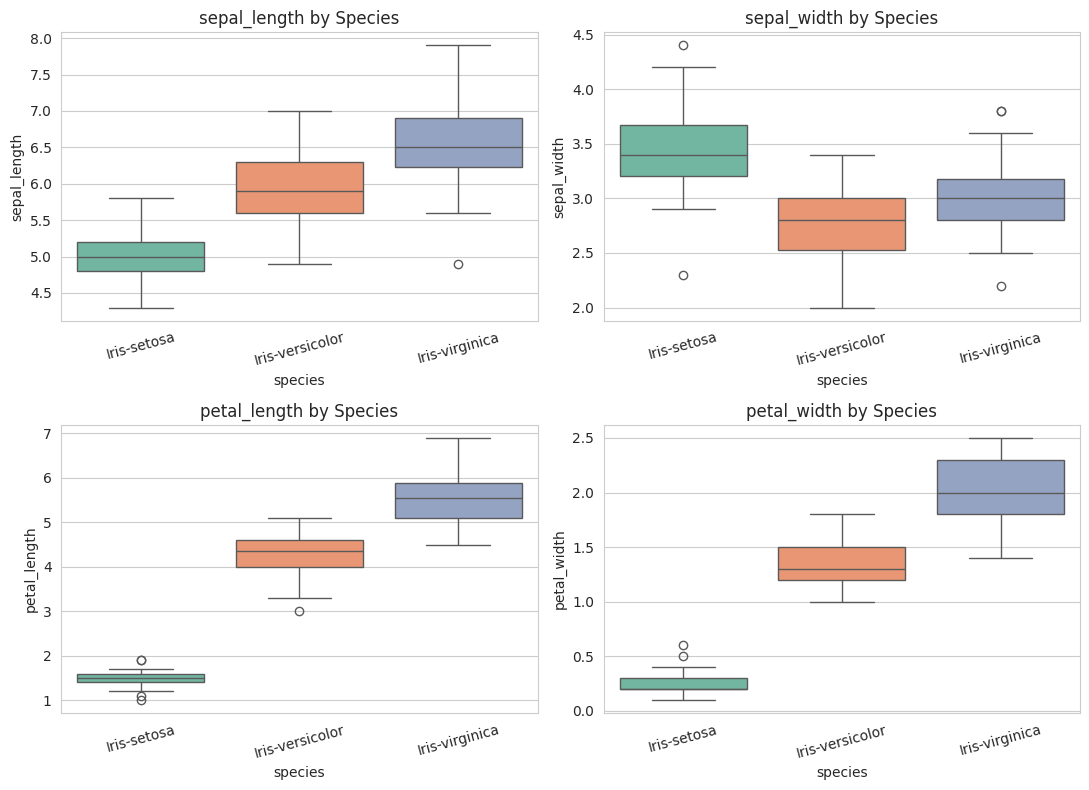

In [18]:
# Visualize — boxplots of all 4 measurements by species
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(x='species', y=feat, data=iris, ax=ax, hue='species', palette='Set2', legend=False)
    ax.set_title(f'{feat} by Species')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Conclusion

We performed descriptive statistics on two classic datasets:

**Wine dataset (Part 1):**
- Computed group-wise statistics (mean, median, min, max, std) for all 13 chemical properties grouped by the `class` variable.
- Created lists of single-number summaries (mean per class) for key variables — `class_0`, `class_1`, `class_2` differ noticeably in alcohol, malic_acid, and total_phenols.
- Visualized the differences using bar charts and boxplots.

**Iris dataset (Part 2):**
- Used `df[df.species == X].describe()` to get full statistical details (count, mean, std, min, 25/50/75 percentiles, max) for each species separately.
- Confirmed that **petal measurements separate species better than sepal measurements** — Iris-setosa is clearly distinguishable from the others.
- Combined all three species into a single comparison table using `groupby`.

**Key insight:** descriptive statistics by themselves don't predict anything — but they're essential for understanding your data, spotting outliers, and informing model choices.

## Explanation of Everything Used in This Notebook

### Libraries

| Library | Purpose |
|---------|---------|
| **pandas** | DataFrames, groupby, describe, agg |
| **numpy** | Numerical operations |
| **matplotlib.pyplot** | Base plotting |
| **seaborn** | Cleaner statistical visualization (boxplots) |

### Functions and Methods Used

#### Loading & Inspection
- `pd.read_csv(path)` — load CSV
- `df.shape`, `df.head()`, `df.info()`, `df.describe()`
- `df['col'].value_counts()` — count occurrences of each category

#### Statistical Summary Methods (per Series)
- `.mean()` — average
- `.median()` — middle value
- `.std()` — standard deviation
- `.var()` — variance
- `.min()`, `.max()` — extremes
- `.quantile(q)` — percentile (e.g., 0.25, 0.5, 0.75)
- `.describe()` — count, mean, std, min, 25%, 50%, 75%, max all at once

#### Group Operations
- `df.groupby('col')` — split DataFrame into groups by a categorical column
- `.agg(['mean', 'median', 'std'])` — apply multiple statistics at once
- `.tolist()` — convert pandas Series to Python list

#### Filtering
- `df[df['species'] == 'value']` — boolean indexing to filter rows

#### Visualization
- `sns.boxplot(x=cat, y=num, data=df)` — boxplot per category
- `series.plot(kind='bar')` — bar chart of a Series
- `plt.subplots(rows, cols, figsize)` — grid of plots
- `plt.tight_layout()` — auto-adjust spacing

### Key Concepts

#### Mean, Median, Mode
- **Mean** = sum / count; sensitive to outliers
- **Median** = middle value when sorted; robust
- **Mode** = most frequent value; works for any data type

#### Standard Deviation vs Variance
- **Variance** = average squared deviation from mean
- **Standard deviation** = √variance — same units as data, easier to interpret

#### Percentiles
A **percentile** is the value below which a given percentage of data falls.
- **25th percentile (Q1)** — 25% of data is below this
- **50th percentile (median)** — 50% below
- **75th percentile (Q3)** — 75% below

#### IQR (Interquartile Range)
**IQR = Q3 − Q1**, the spread of the middle 50% of data. Robust to outliers — used for outlier detection (Tukey's rule).

#### Group-wise Statistics
Computing statistics within categories rather than across the whole dataset. Often more meaningful — e.g., "average income" is less useful than "average income by age group."

The pandas pattern: **`.groupby(category).agg([statistic])`**

#### Why Use Multiple Statistics?
- **Mean alone** is misleading for skewed data
- **Median alone** ignores spread
- **Std alone** doesn't tell you the center
- Together they give a complete picture

#### What `describe()` Returns

| Stat | Meaning |
|------|---------|
| count | number of non-NaN values |
| mean | arithmetic average |
| std | standard deviation |
| min | smallest value |
| 25% | first quartile (Q1) |
| 50% | median (Q2) |
| 75% | third quartile (Q3) |
| max | largest value |

## Viva Questions (with Answers)

### Conceptual

**Q1. What is descriptive statistics?**
Branch of statistics that summarizes and describes the main features of a dataset using numbers (mean, median, std, etc.).

**Q2. Difference between descriptive and inferential statistics?**
- **Descriptive** — summarizes the data you have
- **Inferential** — generalizes from a sample to a population (hypothesis tests, confidence intervals)

**Q3. What are the two main categories of descriptive statistics?**
- **Central tendency** — where is the center (mean, median, mode)
- **Variability** — how spread out (range, variance, std, IQR)

### Central Tendency

**Q4. Difference between mean and median?**
- **Mean** = arithmetic average; sensitive to outliers
- **Median** = middle value when sorted; robust to outliers

**Q5. When is median preferred over mean?**
When data has outliers or is skewed (e.g., income, house prices).

**Q6. What is the mode?**
Most frequently occurring value. Useful for categorical or discrete data.

**Q7. Can a dataset have multiple modes?**
Yes — **bimodal** (two modes) or **multimodal**. A dataset with no repeated values has no mode.

### Variability

**Q8. What does standard deviation measure?**
The average distance of values from the mean — the spread of the data.

**Q9. Difference between variance and standard deviation?**
- **Variance** is the average squared deviation
- **Std** is the square root of variance — has the same units as the original data, so it's more interpretable

**Q10. What is the range?**
max − min. Simplest measure of spread, but only uses two values.

**Q11. What is the IQR?**
Interquartile Range = Q3 − Q1. Spread of the middle 50% of data. Robust to outliers.

**Q12. What's the difference between IQR and std?**
- **IQR** is robust (uses position only)
- **Std** uses every value, so outliers inflate it

### Percentiles

**Q13. What is a percentile?**
Value below which a given % of the data falls. The 25th percentile means 25% of values are smaller.

**Q14. What is the 50th percentile equivalent to?**
The median.

**Q15. How are quartiles related to percentiles?**
Q1 = 25th percentile, Q2 = 50th percentile (median), Q3 = 75th percentile.

### Practical / Code

**Q16. What does `describe()` return?**
count, mean, std, min, 25%, 50%, 75%, max for every numeric column.

**Q17. How do you compute statistics by category?**
Using `df.groupby('category').agg([stat1, stat2, ...])` or `df.groupby('category')['col'].mean()`.

**Q18. What does `.tolist()` do on a pandas Series?**
Converts the Series to a regular Python list.

**Q19. Why group statistics by a categorical variable?**
To see how a numeric variable behaves within each group, revealing patterns hidden in the overall summary.

**Q20. What's the difference between `.mean()` and `.agg('mean')`?**
- `.mean()` returns the mean directly
- `.agg(...)` is more flexible — accepts a list of statistics or custom functions

**Q21. What does `.value_counts()` do?**
Counts unique values in a Series, sorted by frequency.

### Comparison

**Q22. When is mean misleading?**
- Data has outliers (extreme values dominate)
- Data is highly skewed (long tail)
- Data has multiple modes (no single "center")

**Q23. Why are descriptive statistics important before modeling?**
- Spot outliers and missing values
- Understand feature ranges (informs scaling decisions)
- Reveal class imbalance
- Suggest which features may be predictive

**Q24. What other statistics could you compute?**
- **Skewness** — asymmetry of distribution
- **Kurtosis** — tail heaviness
- **Coefficient of variation** = std/mean (relative variability)
- **MAD (Median Absolute Deviation)** — robust spread

**Q25. Difference between population and sample statistics?**
- **Population** — all members; uses N in variance denominator
- **Sample** — a subset; uses (n−1) in variance denominator (Bessel's correction)
Pandas uses sample formulas by default.